In [1]:
import os
import re
import glob
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, classification_report
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


# performance results

In [2]:
import pandas as pd
import glob
import os
from sklearn.metrics import accuracy_score, f1_score, classification_report

In [3]:
all_results = pd.DataFrame()
files = glob.glob("results_hf/*.csv")
files.extend(glob.glob("results_gpt/*full.csv"))
for file in files:
    if "summary" not in file:
        df = pd.read_csv(file)
        if len(df) != 2923:
            continue

        model_name = file.split("/")[-1].replace(".csv", "").split("_")[0]
        df["prompt_template"] = file.split("/")[-1].replace(".csv", "").replace(f"{model_name}_", "").replace("_full", "").replace("_news_articles_leaning_subsampled_neutral", "")
        df["model"] = model_name
        all_results = pd.concat([all_results, df], ignore_index=True)

In [4]:
results = {}
for prompt_template in all_results.prompt_template.unique():
    for model_name in all_results.model.unique():   
        tmp = all_results[(all_results.prompt_template == prompt_template) & (all_results.model == model_name)].copy()
        tmp["gold"] = tmp["gold"].fillna("na")
        tmp["prediction"] = tmp["prediction"].fillna("na")
        report_dict = classification_report(tmp.gold, tmp.prediction, output_dict=True, zero_division=0)
        results[(prompt_template, model_name)] = {
            label: {"precision": scores["precision"], "recall": scores["recall"], "f1-score": scores["f1-score"]}
            for label, scores in report_dict.items()
            if label != "accuracy"
        }

# sort prompt templates from best to worst avg (macro) f1-score
sorted_prompt_templates = sorted(
    results.items(),
    key=lambda x: x[1]["macro avg"]["f1-score"],
    reverse=True
)
# # print the sorted results
# for (prompt_template, model_name), label_scores in sorted_prompt_templates:
#     print(f"Prompt Template: {prompt_template}, Model: {model_name} (macro avg f1-score: {label_scores['macro avg']['f1-score']:.3f})")
#     display(pd.DataFrame(label_scores).transpose())

In [5]:
# create dataframe with number of 'na' responses per model and prompt_template
na_df = all_results.groupby(['model', 'prompt_template']).agg(
    na_count=('prediction', lambda x: ((x == 'na') | x.isna()).sum()),
    total=('prediction', 'size')
).reset_index()
na_df['na_fraction'] = na_df['na_count'] / na_df['total']
na_df = na_df.drop(columns=['total'])  # drop the total column as it's not needed

# sort and show
na_df.sort_values('na_count', ascending=False, inplace=True, ignore_index=True)
na_df[:10]

,model,prompt_template,na_count,na_fraction
0,gpt-5.4-mini,zero_13,7,0.002395
1,meta-llama-Llama-3.3-70B-Instruct,zero_5,2,0.000684
2,meta-llama-Llama-3.3-70B-Instruct,zero_4_v4,2,0.000684
3,meta-llama-Llama-3.3-70B-Instruct,zero_7,1,0.000342
4,meta-llama-Llama-3.3-70B-Instruct,zero_9,1,0.000342
5,meta-llama-Llama-3.3-70B-Instruct,zero_6,1,0.000342
6,meta-llama-Llama-3.3-70B-Instruct,zero_3,1,0.000342
7,meta-llama-Llama-3.3-70B-Instruct,zero_2,1,0.000342
8,meta-llama-Llama-3.3-70B-Instruct,zero_12,1,0.000342
9,meta-llama-Llama-3.3-70B-Instruct,zero_11,1,0.000342


In [7]:
f1_macro_df = pd.DataFrame([
    {"prompt_template": prompt_template, "model": model_name, "f1_macro": label_scores["macro avg"]["f1-score"]}
    for (prompt_template, model_name), label_scores in results.items()
])

# keep only model/prompt_template combos with a na_fraction below 2%
f1_macro_df = f1_macro_df.merge(na_df[["model", "prompt_template", "na_fraction"]], on=["model", "prompt_template"], how="left")
f1_macro_df = f1_macro_df[f1_macro_df["na_fraction"] < 0.01]

f1_macro_pivot = f1_macro_df.pivot(index="prompt_template", columns="model", values="f1_macro")
# change index row by list of numbers from 1 to len(f1_macro_pivot)
# f1_macro_pivot.index = [f"Prompt {i}" for i in range(1, len(f1_macro_pivot) + 1)]
# order rows by the average f1_macro score across models
f1_macro_pivot["f1_across_open_models"] = f1_macro_pivot[["Qwen-Qwen3.6-27B", "google-gemma-4-31B-it", "Qwen-Qwen3.5-27B", "meta-llama-Llama-3.3-70B-Instruct"]].mean(axis=1) #"meta-llama-Llama-3.3-70B-Instruct"
f1_macro_pivot.sort_values(by="f1_across_open_models", ascending=False, inplace=True, ignore_index=False)
print("F1 macro scores for each model and prompt template\n (only showing those with <1% 'na' responses):")
f1_macro_pivot
# print(f1_macro_pivot.to_latex(index=True, float_format="%.3f"))



F1 macro scores for each model and prompt template
 (only showing those with <1% 'na' responses):


model,Qwen-Qwen3.5-27B,Qwen-Qwen3.6-27B,google-gemma-4-31B-it,gpt-5.4-mini,meta-llama-Llama-3.3-70B-Instruct,f1_across_open_models
prompt_template,,,,,,
Zero-shot_1,0.710604,0.729922,0.705530,0.741650,0.708214,0.713568
zero_8,0.708057,0.721391,0.700807,0.734160,0.712727,0.710745
Zero-shot-3v2,0.702917,0.721242,0.705532,0.729366,0.712623,0.710578
zero_13,0.677763,0.661979,0.628647,0.491438,0.720445,0.672208
zero_12,0.729622,0.719584,0.697136,0.716264,0.514063,0.665101
zero_3,0.731757,0.713910,0.672155,0.721924,0.533446,0.662817
zero_6,0.717355,0.708742,0.678857,0.728258,0.536300,0.660313
zero_4_v4,0.719058,0.700668,0.683836,0.727740,0.528172,0.657934
zero_7,0.719407,0.706049,0.669558,0.732490,0.536535,0.657887


In [30]:
gemma = all_results[(all_results.prompt_template == "Zero-shot_1") & (all_results.model == "google-gemma-4-31B-it")]
results = classification_report(gemma.gold, gemma.prediction, output_dict=True, zero_division=0)
df_results = pd.DataFrame(results).transpose()
print(df_results.to_latex(formatters={"precision": "{:.3f}", "recall": "{:.3f}", "f1-score": "{:.3f}", "support": "{:.0f}"}))
# print(df_results.to_markdown())

\begin{tabular}{lrrrr}
\toprule
 & precision & recall & f1-score & support \\
\midrule
left & 0.865 & 0.502 & 0.635 & 1148 \\
neutral & 0.591 & 0.910 & 0.717 & 1148 \\
right & 0.871 & 0.681 & 0.765 & 627 \\
accuracy & 0.701 & 0.701 & 0.701 & 1 \\
macro avg & 0.776 & 0.698 & 0.706 & 2923 \\
weighted avg & 0.759 & 0.701 & 0.695 & 2923 \\
\bottomrule
\end{tabular}



In [39]:
qwen = all_results[(all_results.prompt_template == "Zero-shot_1") & (all_results.model == "Qwen-Qwen3.5-27B")]
results = classification_report(qwen.gold, qwen.prediction, output_dict=True, zero_division=0)
df_results = pd.DataFrame(results).transpose()
print(df_results.to_latex(formatters={"precision": "{:.3f}", "recall": "{:.3f}", "f1-score": "{:.3f}", "support": "{:.0f}"}))
# print(df_results.to_markdown())

\begin{tabular}{lrrrr}
\toprule
 & precision & recall & f1-score & support \\
\midrule
left & 0.862 & 0.506 & 0.638 & 1148 \\
neutral & 0.610 & 0.897 & 0.726 & 1148 \\
right & 0.813 & 0.727 & 0.768 & 627 \\
accuracy & 0.707 & 0.707 & 0.707 & 1 \\
macro avg & 0.762 & 0.710 & 0.711 & 2923 \\
weighted avg & 0.753 & 0.707 & 0.700 & 2923 \\
\bottomrule
\end{tabular}



In [40]:
ensemble = gemma[["prompt_id", "gold"]].merge(
    qwen[["prompt_id", "prediction"]], on="prompt_id"
).merge(
    gemma[["prompt_id", "prediction"]], on="prompt_id", suffixes=("_qwen", "_gemma")
)

def resolve_ensemble(row):
    qwen_pred, gemma_pred = row["prediction_qwen"], row["prediction_gemma"]
    if qwen_pred == gemma_pred:
        return qwen_pred
    pair = {qwen_pred, gemma_pred}
    if pair == {"left", "neutral"}:
        return "left"
    if pair == {"right", "neutral"}:
        return "right"
    # left vs right: opposite extremes, default to qwen
    return gemma_pred

ensemble["prediction"] = ensemble.apply(resolve_ensemble, axis=1)
emsemble_gemma_qwen = ensemble

results = classification_report(
    emsemble_gemma_qwen.gold, emsemble_gemma_qwen.prediction, output_dict=True, zero_division=0
)
df_results = pd.DataFrame(results).transpose()
print(df_results.to_markdown())
print(df_results.to_latex(formatters={"precision": "{:.3f}", "recall": "{:.3f}", "f1-score": "{:.3f}", "support": "{:.0f}"}))


|              |   precision |   recall |   f1-score |     support |
|:-------------|------------:|---------:|-----------:|------------:|
| left         |    0.834146 | 0.595819 |   0.695122 | 1148        |
| neutral      |    0.650856 | 0.860627 |   0.741185 | 1148        |
| right        |    0.803419 | 0.749601 |   0.775578 |  627        |
| accuracy     |    0.732809 | 0.732809 |   0.732809 |    0.732809 |
| macro avg    |    0.762807 | 0.735349 |   0.737295 | 2923        |
| weighted avg |    0.755568 | 0.732809 |   0.730471 | 2923        |
\begin{tabular}{lrrrr}
\toprule
 & precision & recall & f1-score & support \\
\midrule
left & 0.834 & 0.596 & 0.695 & 1148 \\
neutral & 0.651 & 0.861 & 0.741 & 1148 \\
right & 0.803 & 0.750 & 0.776 & 627 \\
accuracy & 0.733 & 0.733 & 0.733 & 1 \\
macro avg & 0.763 & 0.735 & 0.737 & 2923 \\
weighted avg & 0.756 & 0.733 & 0.730 & 2923 \\
\bottomrule
\end{tabular}



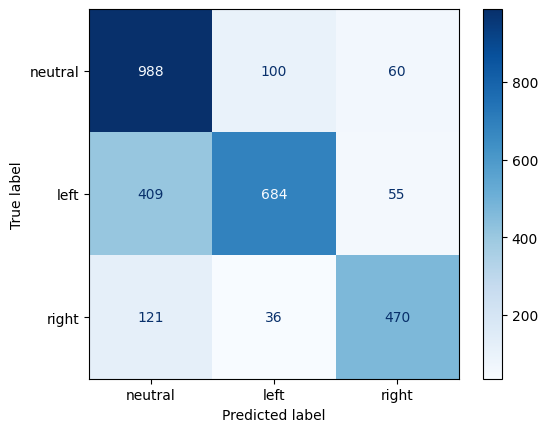

In [42]:
# plot confusion matrix for tmp_best
cm = confusion_matrix(emsemble_gemma_qwen.gold, emsemble_gemma_qwen.prediction, labels=emsemble_gemma_qwen.gold.unique())
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=emsemble_gemma_qwen.gold.unique())
disp.plot(cmap=plt.cm.Blues)


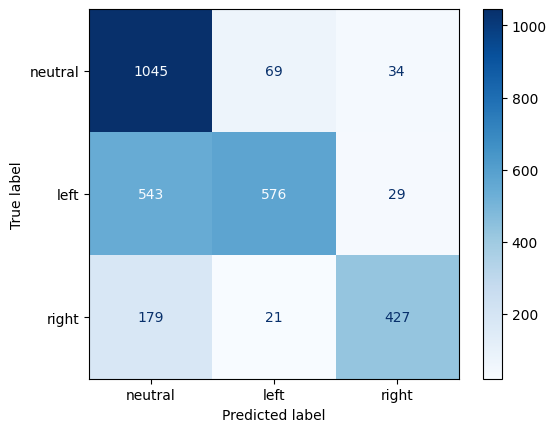

In [29]:
# plot confusion matrix for tmp_best
cm = confusion_matrix(gemma.gold, gemma.prediction, labels=gemma.gold.unique())
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=gemma.gold.unique())
disp.plot(cmap=plt.cm.Blues)